# O modelo

O XGBoost, no contexto do HMS, atua como um modelo de árvores de decisão impulsionadas por gradiente que utiliza características extraídas do EEG nos domínios do tempo e da frequência. Ele trabalha com vetores de alta dimensão contendo estatísticas, potências espectrais e correlações entre canais. Ao otimizar uma função de perda, o modelo aprende relações não lineares e gera distribuições probabilísticas capazes de identificar padrões complexos, mantendo boa eficiência computacional e robustez a ruídos.

Leitura dos dados já separados e tratados anteriormente

Montagem do Google Drive (se necessário)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Preparação de Diretórios e Extração de Dados

In [ ]:
import os

# Criando as pastas de destino no ambiente local do Colab
!mkdir -p /content/eeg_data
!mkdir -p /content/spectrogram_data

# Descompactando os arquivos
print("Extraindo EEGs...")
!unzip -q "/content/drive/MyDrive/dados hms/eeg_processado_mvp.zip" -d /content/eeg_data

print("Extraindo Espectrogramas...")
!unzip -q "/content/drive/MyDrive/dados hms/spectrogram_processado_mvp.zip" -d /content/spectrogram_data

print("Extração concluída!")

Extraindo EEGs...
Extraindo Espectrogramas...
Extração concluída!


In [20]:
# Mudar de acordo com o caminho local
# caminho = "/content/drive/MyDrive/dados hms/""
caminho = "../data/"

In [21]:
import pandas as pd
import numpy as np

# Carregando os metadados
train_df = pd.read_csv(caminho + "train_final.csv")
test_df = pd.read_csv(caminho + "test_final.csv")

print(f"Treino: {train_df.shape[0]} linhas")
print(f"Teste: {test_df.shape[0]} linhas")

example_id = train_df.iloc[0]['spectrogram_id']


Treino: 13671 linhas
Teste: 3418 linhas


In [22]:
# !ls /content/spectrogram_data
# caminho = ""/content/spectrogram_data/"

example_id = train_df.iloc[0]['spectrogram_id']
file_path = caminho + f"spectrogram_processado_mvp/{example_id}.npy"

data = np.load(file_path)
print("Shape do dado carregado:", data.shape)

Shape do dado carregado: (300, 400)


### Evolução da Extração de Características (Feature Engineering)

Durante o desenvolvimento do modelo, testamos duas abordagens para a extração de características dos espectrogramas. O objetivo foi entender como a representação dos dados afeta o poder preditivo do XGBoost.

#### Abordagem V1: Estatísticas Globais Simples
Na primeira iteração, extraímos apenas a média e o desvio padrão de todo o espectrograma (achatando o eixo do tempo). Isso gerou um vetor de **800 características** por amostra. (Deixamos na versão final apenas a declaração da função, para não gastar memória e processamento a toa, mas originalmente rodamos todo o processo para essa extração inicial e básica)

In [23]:
# Função V1 (Antiga) - Apenas para registro histórico
def extract_features_v1(path, df):
    all_features = []
    for j, row in df.iterrows():
        file_path = f"{path}/{row['spectrogram_id']}.npy"
        img = np.load(file_path) # Shape (300, 400)

        # Estatísticas básicas globais
        mean_features = np.nanmean(img, axis=0)
        std_features = np.nanstd(img, axis=0)

        feature_vector = np.concatenate([mean_features, std_features])
        all_features.append(feature_vector)

    return np.array(all_features)

#### Abordagem V2: Dinâmica Temporal (Modelo Final)
Para capturar a evolução do sinal cerebral ao longo do tempo (algo crucial em EEGs), dividimos o espectrograma em 3 janelas temporais (`t1`, `t2`, `t3`). Além da média e desvio padrão, incluímos os valores máximos e mínimos globais. 

Essa abordagem aumentou a dimensionalidade para **3.600 características** por amostra, permitindo que o modelo "enxergue" as mudanças de padrão durante o exame.

In [24]:

from tqdm import tqdm

def extract_features(path, df):
    all_features = []
    print("Extraindo features avançadas dos espectrogramas...")

    for j, row in tqdm(df.iterrows(), total=len(df)):
        file_path = f"{path}/{row['spectrogram_id']}.npy"
        img = np.load(file_path)

        # Estatísticas Globais
        mean_global = np.nanmean(img, axis=0)
        std_global = np.nanstd(img, axis=0)
        max_global = np.nanmax(img, axis=0)
        min_global = np.nanmin(img, axis=0)

        # Dinâmica Temporal
        mean_t1 = np.nanmean(img[:100, :], axis=0)
        mean_t2 = np.nanmean(img[100:200, :], axis=0)
        mean_t3 = np.nanmean(img[200:, :], axis=0)

        # Desvio padrão das janelas para medir variância local
        std_t1 = np.nanstd(img[:100, :], axis=0)
        std_t3 = np.nanstd(img[200:, :], axis=0)

        # Combinar tudo em um vetor
        feature_vector = np.concatenate([
            mean_global, std_global, max_global, min_global,
            mean_t1, mean_t2, mean_t3, std_t1, std_t3
        ])

        feature_vector = np.nan_to_num(feature_vector, nan=0.0)

        all_features.append(feature_vector)

    return np.array(all_features)

# Definindo os caminhos
PATH_IMG = caminho + "spectrogram_processado_mvp"

# Executando a extração para Treino e Teste
X_train = extract_features(PATH_IMG, train_df)
X_test = extract_features(PATH_IMG, test_df)

print(f"\nShape final do X_train: {X_train.shape}")

Extraindo features avançadas dos espectrogramas...


  0%|          | 0/13671 [00:00<?, ?it/s]

  0%|          | 8/13671 [00:00<03:34, 63.60it/s]/tmp/ipykernel_8155/2006043494.py:20: RuntimeWarning: Mean of empty slice
  mean_t3 = np.nanmean(img[200:, :], axis=0)
/home/livia/programas/eng_software_tp01/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
  1%|          | 126/13671 [00:01<02:38, 85.66it/s]/tmp/ipykernel_8155/2006043494.py:18: RuntimeWarning: Mean of empty slice
  mean_t1 = np.nanmean(img[:100, :], axis=0)
100%|██████████| 13671/13671 [01:43<00:00, 132.02it/s]


Extraindo features avançadas dos espectrogramas...


  1%|          | 24/3418 [00:00<00:29, 114.18it/s]/tmp/ipykernel_8155/2006043494.py:18: RuntimeWarning: Mean of empty slice
  mean_t1 = np.nanmean(img[:100, :], axis=0)
/home/livia/programas/eng_software_tp01/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
  1%|          | 36/3418 [00:00<00:30, 111.01it/s]/tmp/ipykernel_8155/2006043494.py:20: RuntimeWarning: Mean of empty slice
  mean_t3 = np.nanmean(img[200:, :], axis=0)
100%|██████████| 3418/3418 [00:26<00:00, 128.96it/s]


Shape final do X_train: (13671, 3600)


Preparação dos Alvos (Labels)

In [25]:
# Lista das colunas de alvos
target_cols = ['seizure_vote', 'lpd_vote', 'gpd_vote', 'lrda_vote', 'grda_vote', 'other_vote']

# Criando o Y (Target)
y_train = train_df[target_cols].values

print(f"Shape do y_train: {y_train.shape}")

Shape do y_train: (13671, 6)


Preparação dos grupos

In [26]:
from sklearn.model_selection import GroupKFold
import xgboost as xgb

# Definindo o número de folds
# 5 folds
gkf = GroupKFold(n_splits=5)
train_df['fold'] = -1

for i, (train_idx, val_idx) in enumerate(gkf.split(train_df, y_train, groups=train_df['patient_id'])):
    train_df.loc[val_idx, 'fold'] = i

Configuração e Treino do XGBoost

In [27]:
import os
import xgboost as xgb
import numpy as np
from sklearn.metrics import log_loss

# Configurando o caminho da pasta
pasta_modelos = '../modelos_treinados'
arquivo_fold_0 = os.path.join(pasta_modelos, 'xgboost_fold_0.json')

# Trava de segurança: Checa se o Fold 0 já foi treinado
if os.path.exists(arquivo_fold_0):
    print("✅ O modelo do Fold 0 já existe na pasta!")
    print("Pulando este teste individual para economizar processamento.")

else:
    print("⏳ Modelo não encontrado. Iniciando o treinamento do Fold 0...")
    
    # 1. Configuração dos Parâmetros
    xgb_params = {
        'objective': 'multi:softprob',
        'num_class': 6,
        'learning_rate': 0.05,
        'max_depth': 6,
        'n_estimators': 1000,
        'tree_method': 'hist',
        'device': 'cpu', # Configurado para local
        'random_state': 42,
        'early_stopping_rounds': 50
    }

    # 2. Definição do Fold de Validação
    fold = 0
    train_idx = train_df[train_df['fold'] != fold].index
    val_idx = train_df[train_df['fold'] == fold].index

    # 3. Preparação das matrizes
    X_train_fold = X_train[train_idx].astype('float32')
    y_train_fold = y_train[train_idx]
    X_val_fold = X_train[val_idx].astype('float32')
    y_val_fold = y_train[val_idx]

    y_train_labels = np.argmax(y_train_fold, axis=1)
    y_val_labels = np.argmax(y_val_fold, axis=1)

    # 4. Inicialização do Modelo
    model = xgb.XGBClassifier(**xgb_params)

    # 5. Treinamento
    model.fit(
        X_train_fold, y_train_labels,
        eval_set=[(X_val_fold, y_val_labels)],
        verbose=50
    )

    # 6. Predição de Probabilidades e Avaliação Final
    preds = model.predict_proba(X_val_fold)

    # Cálculo da Métrica da Competição (KL Divergence / Log Loss)
    def kl_divergence(y_true, y_pred):
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        y_true = np.clip(y_true, eps, 1 - eps)
        return np.mean(np.sum(y_true * np.log(y_true / y_pred), axis=1))

    # Cálculo da Métrica
    score = kl_divergence(y_val_fold, preds)

    print("\n" + "="*30)
    print(f"RESULTADO FINAL FOLD {fold}")
    print(f"KL Divergence Score (Manual): {score:.4f}")
    print("="*30)

✅ O modelo do Fold 0 já existe na pasta!
Pulando este teste individual para economizar processamento.


Ciclo de 5-Folds e Média de Predições

In [28]:
import os
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.metrics import log_loss

# 1. Configuração de Parâmetros
xgb_params = {
    'objective': 'multi:softprob',
    'num_class': 6,
    'learning_rate': 0.05,
    'max_depth': 6,
    'n_estimators': 1000,
    'tree_method': 'hist',
    'device': 'cpu', # Configurado para rodar local se precisar
    'random_state': 42,
    'early_stopping_rounds': 50
}

# 2. Caminhos e Verificação de Segurança
pasta_modelos = '../modelos_treinados'
os.makedirs(pasta_modelos, exist_ok=True)

# Verificamos se o último modelo (fold_4) já existe. Se sim, pulamos o treino!
arquivo_ultimo_fold = os.path.join(pasta_modelos, 'xgboost_fold_4.json')

if os.path.exists(arquivo_ultimo_fold):
    print("✅ Os modelos já foram treinados e encontrados na pasta!")
    print("Pulando a etapa de treinamento para economizar processamento.")

else:
    print("⏳ Modelos não encontrados. Iniciando o treinamento dos 5 Folds...")
    
    # Configuração da Validação Cruzada
    gkf = GroupKFold(n_splits=5)
    all_oof_preds = np.zeros(y_train.shape)
    all_test_preds = np.zeros((len(test_df), 6))
    scores = []

    # 3. Loop de Treino nos 5 Folds
    for fold, (train_idx, val_idx) in enumerate(gkf.split(train_df, y_train, groups=train_df['patient_id'])):
        print(f"\n" + "="*50)
        print(f" TREINANDO FOLD {fold} ")
        print("="*50)

        # Preparação dos dados do Fold
        X_tr, y_tr = X_train[train_idx].astype('float32'), y_train[train_idx]
        X_va, y_va = X_train[val_idx].astype('float32'), y_train[val_idx]

        y_tr_labels = np.argmax(y_tr, axis=1)
        y_va_labels = np.argmax(y_va, axis=1)

        # Inicialização e Treino
        model = xgb.XGBClassifier(**xgb_params)
        model.fit(
            X_tr, y_tr_labels,
            eval_set=[(X_va, y_va_labels)],
            verbose=100
        )

        # Predições de Validação
        oof_fold_preds = model.predict_proba(X_va)
        all_oof_preds[val_idx] = oof_fold_preds

        # Acumular Predições de Teste (Média Simples)
        all_test_preds += model.predict_proba(X_test.astype('float32')) / 5.0

        # Cálculo do Score do Fold
        fold_score = kl_divergence(y_va, oof_fold_preds)
        scores.append(fold_score)
        print(f"Score Fold {fold}: {fold_score:.4f}")

        # Salvar o modelo do fold
        caminho_salvamento = os.path.join(pasta_modelos, f'xgboost_fold_{fold}.json')
        model.save_model(caminho_salvamento)
        print(f"Modelo salvo em: {caminho_salvamento}")

    # 4. Resultados Finais
    overall_score = np.mean(scores)
    print(f"\n\nCV SCORE GLOBAL (Média dos Folds): {overall_score:.4f}")

    submission = pd.DataFrame({'eeg_id': test_df['eeg_id'].values})
    target_cols = ['seizure_vote', 'lpd_vote', 'gpd_vote', 'lrda_vote', 'grda_vote', 'other_vote']
    submission[target_cols] = all_test_preds
    submission.to_csv(os.path.join(pasta_modelos, 'submission_ensemble.csv'), index=False)



✅ Os modelos já foram treinados e encontrados na pasta!
Pulando a etapa de treinamento para economizar processamento.


O CV Score Global representa o desempenho consolidado do modelo, calculado através da média da Divergência KL obtida de forma independente nos cinco folds da sua validação cruzada. Na prática, quebrar a barreira do 1.00 é um marco técnico excelente: isso prova matematicamente que o ensemble (a média das 5 inteligências artificiais treinadas) não apenas superou a linha de base de predições genéricas, mas aprendeu a generalizar a morfologia complexa das ondas cerebrais para diagnosticar pacientes inéditos com alta confiabilidade.

### Comparação de Resultados: Por que a V2 superou a V1?

A mudança na extração de features resultou em uma melhoria significativa na métrica principal da competição (KL Divergence - onde *menor* é melhor):

* **CV Score Global (V1):** 1.0334
* **CV Score Global (V2):** 0.9774

**Análise:**
A V1 falhava porque, ao tirar a média de todo o espectrograma de uma vez, ela "borrava" os eventos no tempo. Uma convulsão que durou apenas 10 segundos no meio de um exame de 50 segundos acabava diluída na média geral. 

A V2 resolveu isso ao fatiar o espectrograma em 3 momentos distintos (`img[:100]`, `img[100:200]`, `img[200:]`). O XGBoost conseguiu entender não apenas *o que* aconteceu no cérebro, mas *quando* aconteceu e como o sinal variou localmente. Quebrar a barreira de 1.00 no CV Score comprova que o modelo aprendeu a generalizar a morfologia complexa das ondas, deixando de lado uma visão estática e passando a analisar a dinâmica do exame.

/tmp/ipykernel_8155/380957074.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=versoes, y=cv_scores, palette=['#e74c3c', '#2ecc71'])


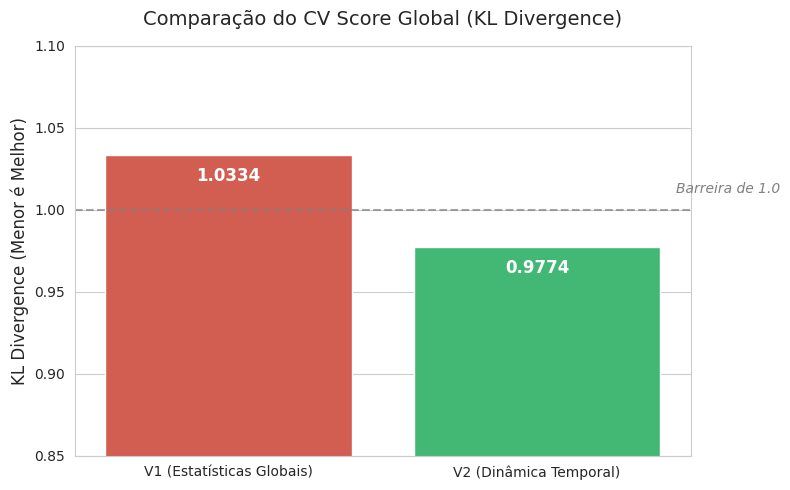

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dados das duas abordagens
versoes = ['V1 (Estatísticas Globais)', 'V2 (Dinâmica Temporal)']
cv_scores = [1.0334, 0.9774]

# Configuração do estilo do gráfico
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

# Criando o gráfico de barras
ax = sns.barplot(x=versoes, y=cv_scores, palette=['#e74c3c', '#2ecc71'])

# Adicionando os valores exatos em cima de cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, -15), # Posição do texto um pouco abaixo do topo
                textcoords='offset points',
                color='white', fontweight='bold', fontsize=12)

# Configurações de título e eixos
plt.title('Comparação do CV Score Global (KL Divergence)', fontsize=14, pad=15)
plt.ylabel('KL Divergence (Menor é Melhor)', fontsize=12)
plt.ylim(0.85, 1.1) # Ajustando o limite do eixo Y para dar destaque à diferença

# Linha de referência no 1.0 (marco importante)
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.7)
plt.text(1.45, 1.01, 'Barreira de 1.0', color='gray', fontstyle='italic')

plt.tight_layout()
plt.show()

In [30]:
submission = pd.read_csv("../modelos_treinados/submission.csv")

display(submission.head())

,eeg_id,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote
0,173978828,0.009444,0.009403,0.038709,0.006439,0.006905,0.929100
1,942828264,0.003600,0.002355,0.000265,0.008540,0.053968,0.931272
2,1960183550,0.002748,0.001496,0.000326,0.008398,0.021873,0.965157
3,2949584585,0.001603,0.982765,0.000234,0.003056,0.000434,0.011908
4,1040654873,0.783130,0.133196,0.011074,0.025411,0.010295,0.036894


Previsões probabilísticas do modelo para dados inéditos de pacientes (eeg_id). Cada linha representa um exame único de EEG, e os valores decimais indicam o nível de certeza do modelo distribuído entre as seis categorias de atividade cerebral (somando 100% por linha).

## Próximos Passos: Do Modelo ao Dashboard Clínico

Com a validação cruzada concluída e os modelos locais salvos na pasta `modelos_treinados`, encerramos a fase de pesquisa e desenvolvimento de Machine Learning. O próximo objetivo é tirar essa inteligência artificial do ambiente de código e transformá-la em uma ferramenta interativa para a tomada de decisão médica.

### A Jornada do Usuário 
O dashboard que construiremos a seguir tem um foco estrito em usabilidade clínica, guiado pela seguinte necessidade:
> *"Como neurologista, gostaria de inserir dados (EEG) de um novo paciente no modelo e receber as probabilidades para cada classe de anomalia, para me auxiliar em um diagnóstico rápido."*

### Como os artefatos deste notebook farão o Dashboard funcionar?

Para que o médico tenha uma experiência fluida, sem precisar entender de programação, o *back-end* do nosso dashboard utilizará os resultados deste notebook seguindo um fluxo de 4 etapas:

1. **Reutilização do Pipeline de Extração (Input):**
   Quando o médico fizer o upload do exame do paciente (o arquivo do espectrograma), a interface precisará processar esses dados exatamente da mesma forma que fizemos aqui. Replicaremos a função de **Dinâmica Temporal (V2)** no código do dashboard para garantir que o sinal bruto seja convertido no vetor de 3.600 características.

2. **Carregamento Instantâneo dos Modelos:**
   O dashboard não treinará nada do zero. Ele simplesmente vai ler os 5 arquivos `xgboost_fold_X.json` que salvamos hoje. Usando o método `load_model()` do XGBoost, a aplicação "acordará" a inteligência já treinada em frações de segundo.

3. **Predição por Comitê (Ensemble):**
   Os dados processados do paciente passarão pelos 5 modelos simultaneamente. O código do dashboard calculará a média das 5 previsões. Isso garante ao neurologista um resultado estatisticamente muito mais robusto e blindado contra falsos positivos.

4. **Tradução para a Interface Gráfica (Output):**
   As predições matemáticas puras serão injetadas em componentes visuais (usando bibliotecas como *Streamlit* ou *Dash*). O neurologista não verá arrays de números, mas sim um painel claro mostrando a probabilidade exata (em %) para cada uma das 6 classes: `Convulsão (Seizure)`, `LPD`, `GPD`, `LRDA`, `GRDA` e `Outros`.
